_Artificial Intelligence for Vision & NLP_ &nbsp; | &nbsp; _ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence_

# Student Submisison

Name : Tope Lawal <br>
Student Number : L00196406 <br>
Due Date : 12 May, 2026 <br>
Assignment : CA2 <br>
Module : AI for Vision and NLP <br>
Course : Postgraduate Diploma in Big Data Analytics and AI


## NLP and Vision Pipeline : High Level

```
┌─────────────────────────────────────────────────────────────────────┐
│                    DOCUMENT INPUT (image file)                      │
└──────────────────────────────┬──────────────────────────────────────┘
                               │
               ┌───────────────▼───────────────┐
               │   1. IMAGE CLASSIFICATION     │
               │   classify_image_type()       │
               │   photo / scan / rendered     │
               └───────────────┬───────────────┘
                               │
               ┌───────────────▼───────────────┐
               │   2. ADAPTIVE PREPROCESSING   │
               │   preprocess_adaptive()       │
               │   CLAHE · denoise · deskew    │
               └──────────┬────────────────────┘
                          │
          ┌───────────────┴────────────────┐
          │                                │
┌─────────▼──────────┐          ┌──────────▼──────────────┐
│  3. OCR PIPELINE   │          │  4. LAYOUT DETECTION     │
│  extract_text()    │          │  detect_and_classify()   │
│  multi-pass PSM    │          │  TEXT / TABLE / IMAGE    │
│  confidence-scored │          │  + ORB feature matching  │
└─────────┬──────────┘          └──────────┬───────────────┘
          │                                │
┌─────────▼──────────┐          ┌──────────▼───────────────┐
│  5. NLP PIPELINE   │          │  6. TABLE EXTRACTION     │
│  clean · tokenise  │          │  extract_table_data()    │
│  stem · lemmatise  │          │  per-region crop + OCR   │
│  NER · TF-IDF      │          └──────────┬───────────────┘
│  sentiment         │                     │
│  section classify  │                     │
└─────────┬──────────┘                     │
          │                                │
          └───────────────┬────────────────┘
                          │
          ┌───────────────▼───────────────┐
          │  7. MULTI-MODAL INTEGRATION   │
          │  generate_document_report()   │
          │  cross-modal reference detect │
          └───────────────┬───────────────┘
                          │
                          ▼
┌─────────────────────────────────────────────────────────────────────┐
│          FINAL OUTPUT  (dashboard and JSON report)                  │
└──────────────────────────────┬──────────────────────────────────────┘

```


# Initialisation

Perform pip installs(or use a requirements.txt) <br>
perform imports


In [489]:
# ── Standard Library ──
from IPython.display import display, HTML
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
import os
import re
import json
from pathlib import Path

# ── Image Processing ──
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── OCR ──
import pytesseract
from pytesseract import Output
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# ── NLP ──
import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from textblob import TextBlob

# Download required NLTK data (safe to re-run)
for pkg in ["punkt", "stopwords", "punkt_tab"]:
    nltk.download(pkg, quiet=True)

stemmer = nltk.stem.PorterStemmer()

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

# Setting global params for matplotlib
plt.rcParams['figure.figsize'] = (20, 20)

print("Good to go! All libraries loaded successfully.")
print(f"OpenCV version: {cv2.__version__}")
print(f"spaCy version:  {spacy.__version__}")


C:\Users\Tope\anaconda3\envs\nlp_env\lib\site-packages\spacy\util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.4). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


Good to go! All libraries loaded successfully.
OpenCV version: 4.13.0
spaCy version:  3.7.4


# Support Functions


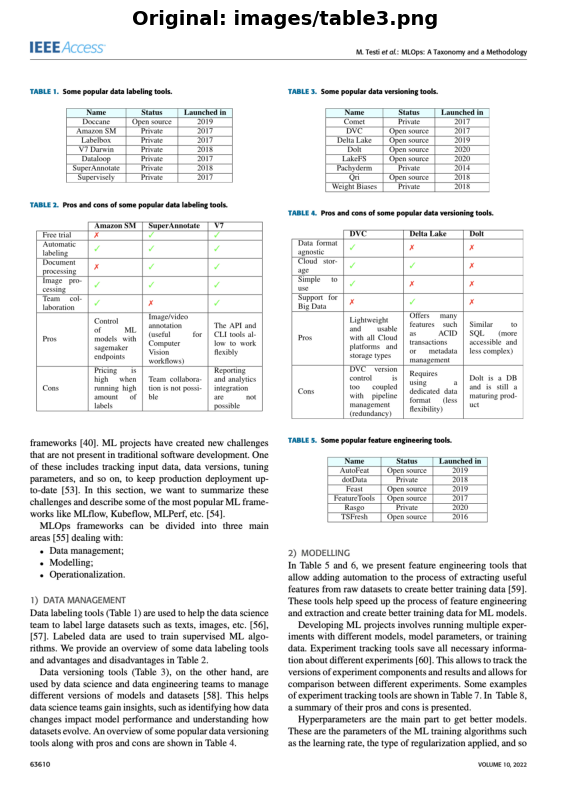

File: images/table3.png
Image shape: (1568, 1154, 3) (Height x Width x Channels)


In [490]:
# image path
IMAGE_PATHS = [r"images/table.png", r"images/table2.jpg", r"images/table3.png", r"images/image.png", r"images/image2.png", r"images/image3.png",
               r"images/photo.jpeg", r"images/photo2.jpg", r"images/screenshot-test1.png"]
# load image
def load_image(path):
    """Load image using OpenCV and convert to RGB for display."""
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f"Image not found at: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_bgr, img_rgb


def show_image(img_rgb, title="Document", figsize=(12, 8)):
    """Display an image with a title using matplotlib."""
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


path = IMAGE_PATHS[2]

img_bgr, img_rgb = load_image(path)
show_image(img_rgb, title=f"Original: {path}")
print(f"File: {path}")
print(f"Image shape: {img_rgb.shape} (Height x Width x Channels)")

# Image Preprocessing


  Document type : RENDERED
  sharpness      : 10818.1
  contrast       : 57.0
  white_ratio    : 0.886
  noise_level    : 13.131
  resolution     : 1154x1568


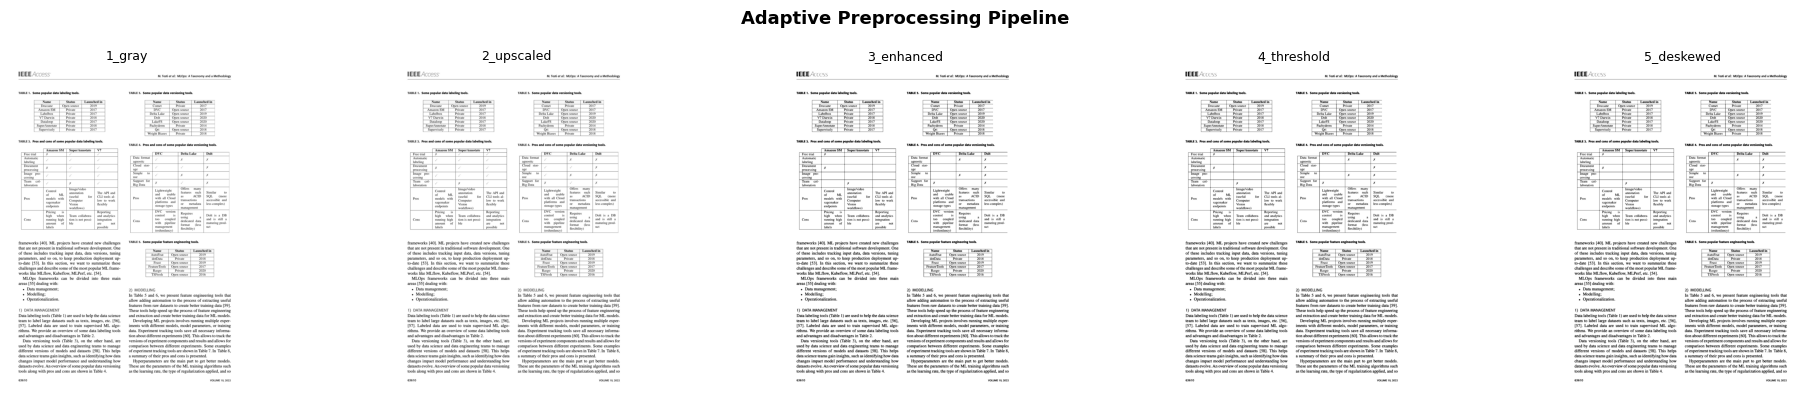

Preprocessing complete.


In [491]:
def classify_image_type(img_bgr):
    """
    Classify document image into one of three types:
      'photo'    — camera photo: noisy, uneven lighting
      'scan'     — scanned document: clean background, moderate sharpness
      'rendered' — PDF/digital render: very sharp, near-perfect white background

    Heuristics:
      - Sharpness via Laplacian variance (high = sharp = rendered/scan)
      - White pixel ratio (high = clean background)
      - Noise level (high = photo)
    """
    #ref: https://docs.opencv.org/3.4/d5/db5/tutorial_laplace_operator.html

    #convert image to gray scale for simpler calculation
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    contrast = gray.std()
    white_pixel_ratio = np.sum(gray > 220) / (h * w)

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    noise_level = np.mean(
        np.abs(gray.astype(float) - blurred.astype(float))
    )

    metrics = {
        "sharpness": round(laplacian_var, 1),
        "contrast": round(float(contrast), 1),
        "white_ratio": round(white_pixel_ratio, 3),
        "noise_level": round(float(noise_level), 3),
        "resolution": f"{w}x{h}",
    }

    if laplacian_var > 1000:
        image_type = "rendered"  # High sharpness likely screenshot/PDF

    elif noise_level > 5.0 or white_pixel_ratio < 0.30:
        image_type = "photo"  # Very high noise or very little white = camera photo

    else:
        image_type = "scan"

    return image_type, metrics


def deskew(binary_img):
    """
    Correct document rotation using minimum area rectangle on dark pixels.
    Skips correction if angle < 0.5 degrees (already straight).
    """
    # ref: https://www.pyimagesearch.com/2017/02/20/text-skew-correction-opencv-python/

    # finds coordinates of dark pixels
    coords = np.column_stack(np.where(binary_img < 128))

    if len(coords) < 100:
        return binary_img

    angle = cv2.minAreaRect(coords)[-1]

    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    if abs(angle) < 0.5:
        return binary_img

    h, w = binary_img.shape

    M = cv2.getRotationMatrix2D(
        (w // 2, h // 2),
        angle,
        1.0,
    )

    return cv2.warpAffine(
        binary_img,
        M,
        (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE,
    )


def remove_shadows(img_bgr):
    """
    Remove uneven lighting / wrinkles from photographed documents.
    """

    #ref: https://opencv.org/shadow-correction-using-opencv/#h-diving-into-the-code-step-by-step-breakdown
    #ref: https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html
    
    # Convert to grayscale
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Dilate to get the "background"
    # (removes the thin text lines)
    dilated_img = cv2.dilate(
        gray,
        np.ones((7, 7), np.uint8),
    )

    # Blur the background to smooth out wrinkles
    bg_img = cv2.medianBlur(dilated_img, 21)

    # Find the difference (Original - Background)
    # This leaves only the text on a clean white surface
    diff_img = 255 - cv2.absdiff(gray, bg_img)

    # Normalize to boost contrast
    norm_img = cv2.normalize(
        diff_img,
        None,
        alpha=0,
        beta=255,
        norm_type=cv2.NORM_MINMAX,
        dtype=cv2.CV_8U,
    )

    return norm_img


def preprocess_adaptive(img_bgr, image_type):
    """
    Simplified preprocessing: Converts any document type into a standardized
    binary layout containing black text on a crisp white background.
       Returns
    -------
    thresh : np.ndarray (Preprocessed binary image)

    stages : dict (Intermediate preprocessing stages)
    """
   #refs: https://docs.opencv.org/4.x/d5/d69/tutorial_py_non_local_means.html
   # https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html
     
    stages = {}

    # Convert directly to grayscale
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    stages["1_gray"] = gray

    # Double the resolution scale factor for OCR accuracy ($2\times$)
    upscaled = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    stages["2_upscaled"] = upscaled

    # Apply global Otsu binarization to separate light and dark regions
    _, thresh = cv2.threshold(upscaled, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # FIX: Ensure it is always black text on a white background.
    # If more than half the pixels are dark (0), it is a dark mode document.
    # We invert it so the background turns white (255) and text turns black (0).
    if np.mean(thresh) < 127:
        thresh = cv2.bitwise_not(thresh)

    stages["3_enhanced"] = thresh
    stages["4_threshold"] = thresh

    # Straighten the text if it is skewed
    final_thresh = deskew(thresh)
    stages["5_deskewed"] = final_thresh

    return final_thresh.astype(np.uint8), stages

def get_detection_params(image_type, img_shape):
    """
    Return adaptive kernel sizes for text block and table detection.

    Rendered docs need smaller kernels (thin 1px lines, dense text).

    Photos need larger kernels (thick lines, lower effective DPI).
    """
    h, w = img_shape[:2]

    if image_type == "rendered":

        return dict(
            text_h=max(10, w // 60),
            text_v=max(8, h // 70),
            table_h=max(20, w // 40),
            table_v=max(20, h // 40),
            min_area=0.0005,
            tbl_min_w=0.03,
            tbl_min_h=0.02,
        )

    elif image_type == "photo":

        return dict(
            text_h=max(20, w // 30),
            text_v=max(10, h // 60),
            table_h=max(40, w // 15),
            table_v=max(40, h // 15),
            min_area=0.001,
            tbl_min_w=0.05,
            tbl_min_h=0.05,
        )

    else:
        # scan
        return dict(
            text_h=max(15, w // 40),
            text_v=max(8, h // 65),
            table_h=max(30, w // 20),
            table_v=max(30, h // 20),
            min_area=0.0008,
            tbl_min_w=0.04,
            tbl_min_h=0.03,
        )


def show_preprocessing_stages(stages):
    """
    Display all preprocessing stages side by side.
    """
    fig, axes = plt.subplots(
        1,
        len(stages),
        figsize=(4 * len(stages), 4),
    )

    if len(stages) == 1:
        axes = [axes]

    for ax, (key, img) in zip(axes, stages.items()):

        ax.imshow(img, cmap="gray")
        ax.set_title(key, fontsize=9)
        ax.axis("off")

    plt.suptitle(
        "Adaptive Preprocessing Pipeline",
        fontsize=13,
        fontweight="bold",
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# CLASSIFY + PREPROCESS
# ------------------------------------------------------------

image_type, metrics = classify_image_type(img_bgr)

print("=" * 50)
print(f"  Document type : {image_type.upper()}")

for k, v in metrics.items():
    print(f"  {k:15s}: {v}")

print("=" * 50)

preprocessed, stages = preprocess_adaptive(
    img_bgr,
    image_type,
)

show_preprocessing_stages(stages)

print("Preprocessing complete.")

# OCR Text Extraction


In [492]:
# TABLE EXTRACTION
# Called per-region after detect_and_classify_elements identifies a TABLE bbox.
# Takes a crop of the original image, removes grid lines, then OCR-reads each cell.

#ref: https://livefiredev.com/how-to-extract-table-from-image-in-python-opencv-ocr/
def extract_table_data(img_bgr, bbox):
    """
    Extract tabular data from a single detected TABLE region.

    Parameters
    ----------
    img_bgr : np.ndarray  – full original BGR image
    bbox    : dict        – {"x", "y", "w", "h"} bounding box of the table region

    Returns
    -------
    list[str]  – one string per row, cells joined with " | "
                 e.g. ["Name | Age | Score", "Alice | 30 | 95"]
                 Returns ["No text found"] if nothing is extracted.
    """

    # refs: https://livefiredev.com/how-to-extract-table-from-image-in-python-opencv-ocr/
    #https://medium.com/@rajashekarganiger2002/detect-and-extract-table-data-using-opencv-3039df2b80b0
    
    x, y, w, h = bbox["x"], bbox["y"], bbox["w"], bbox["h"]
    h_img, w_img = img_bgr.shape[:2]

    # Crop the table region from the full page
    table_crop = img_bgr[
        max(0, y) : min(h_img, y + h),
        max(0, x) : min(w_img, x + w)
    ]

    if table_crop.size == 0:
        return ["Empty region"]

    # 1. THRESHOLD
    gray = cv2.cvtColor(table_crop, cv2.COLOR_BGR2GRAY)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    crop_h, crop_w = thresh.shape

    # 2. REMOVE TABLE LINES
    # Horizontal and vertical kernels (lines) sized relative to the crop 
    hor_k = cv2.getStructuringElement(cv2.MORPH_RECT, (max(20, crop_w // 5), 1))
    ver_k = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(20, crop_h // 5)))

    hor_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, hor_k, iterations=2)
    ver_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, ver_k, iterations=2)

    line_mask = cv2.add(hor_lines, ver_lines)
    line_mask = cv2.dilate(line_mask, np.ones((3, 3), np.uint8), iterations=1)
    clean_thresh = cv2.subtract(thresh, line_mask)

    # 3. DETECT TEXT BLOBS
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 3))
    dilated = cv2.dilate(clean_thresh, kernel, iterations=1)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = [
        cv2.boundingRect(c) for c in contours
        if cv2.boundingRect(c)[2] > 10 and cv2.boundingRect(c)[3] > 10
    ]

    if not boxes:
        return ["No text found"]

    # 4. SORT INTO ROWS
    boxes = sorted(boxes, key=lambda b: b[1])
    avg_h = np.mean([b[3] for b in boxes])

    rows = []
    curr_row = [boxes[0]]
    for i in range(1, len(boxes)):
        #If two boxes are vertically close treat them as same row else: start new row
        if abs(boxes[i][1] - curr_row[-1][1]) < (avg_h * 0.7):
            curr_row.append(boxes[i])
        else:
            rows.append(sorted(curr_row, key=lambda b: b[0]))
            curr_row = [boxes[i]]
    rows.append(sorted(curr_row, key=lambda b: b[0]))

    # 5. OCR EACH CELL
    final_output = []

    for row in rows:
        row_data = []
        for (cx, cy, cw, ch) in row:
            pad = 2
            y1 = max(0, cy - pad)
            y2 = min(crop_h, cy + ch + pad)
            x1 = max(0, cx - pad)
            x2 = min(crop_w, cx + cw + pad)

            cell = table_crop[y1:y2, x1:x2]
            if cell.size == 0:
                continue

            # Upscale + re-threshold for better single-line OCR
            cell_gray = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
            cell_res  = cv2.resize(cell_gray, None, fx=2, fy=2,
                                   interpolation=cv2.INTER_CUBIC)
            _, cell_fin = cv2.threshold(cell_res, 0, 255,
                                        cv2.THRESH_BINARY + cv2.THRESH_OTSU)

            text = pytesseract.image_to_string(
                cell_fin, config="--oem 3 --psm 7"
            ).strip()

            clean_text = "".join(
                c for c in text if c.isalnum() or c in ".,/- "
            ).strip()

            if clean_text:
                row_data.append(clean_text)

        if row_data:
            final_output.append(" | ".join(row_data))

    return final_output if final_output else ["No text found"]


  [OCR Pass] Config: --oem 1 --psm 4 -c preserve_interword_spaces=1 | Words: 706 | Conf: 89.2%
  [OCR Pass] Config: --oem 1 --psm 6 -c preserve_interword_spaces=1 | Words: 640 | Conf: 87.5%
  [OCR Pass] Config: --oem 1 --psm 11 -c preserve_interword_spaces=1 | Words: 653 | Conf: 94.5%

>> WINNING CONFIG: --oem 1 --psm 11 -c preserve_interword_spaces=1 (94.5% confidence)
--------------------------------------------------------------------------------------------------------------------------------------------
EXTRACTED TEXT (RAW)
--------------------------------------------------------------------------------------------------------------------------------------------
IEEE Access

M. Testi et a/.: MLOps: A Taxonomy and a Methodology

TABLE 1. Some popular data labeling tools.

TABLE 3. Some popular data versioning tools.

Name

Status

Launched in

Name

Status

Launched in

Doccane

Open source

2019

Comet

Private

2017

Amazon SM

Private

2017

DVC

Open source

2017

Labelbox

Pri

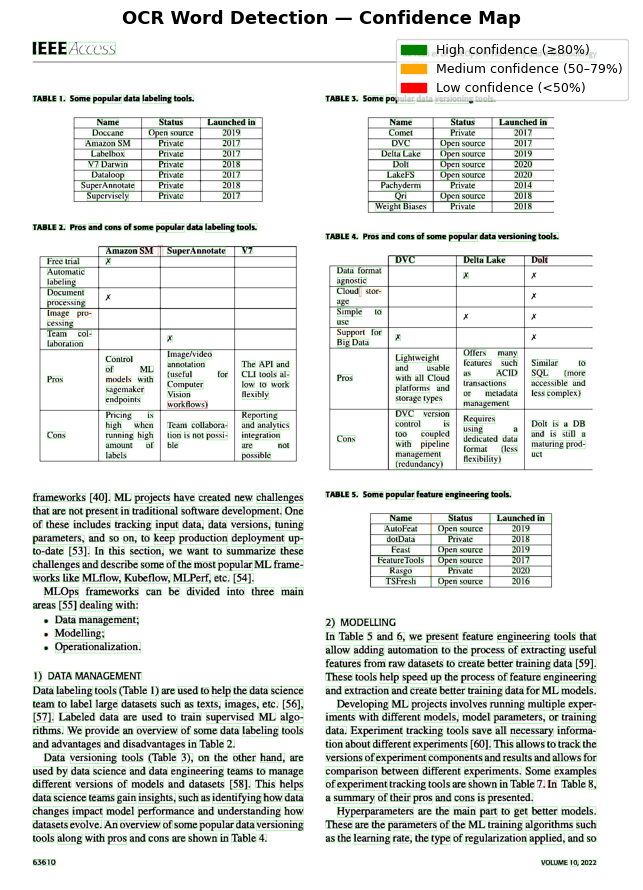

In [493]:
def extract_text(preprocessed_img, original_img_rgb, config=None):
    """
        Extract text from preprocessed image using Tesseract OCR.
         Multi-pass OCR: tries multiple PSM modes and picks best result.

        Args:
            preprocessed_img: Binary preprocessed image
            original_img_rgb: Original image for visualisation
            config: Tesseract config string
                --oem 1: Neural network-based OCR (more accurate but slower).
                --psm 3: Fully automatic page segmentation


        Returns:
            raw_text: Full extracted text string
            word_data: DataFrame with word-level bounding boxes and confidence

    """

    # Better configs for academic docs + tables
    configs = [
        '--oem 1 --psm 4 -c preserve_interword_spaces=1',
        '--oem 1 --psm 6 -c preserve_interword_spaces=1',
        '--oem 1 --psm 11 -c preserve_interword_spaces=1',
    ]

    best_text = ''
    best_word_data = None
    best_score = -1

    for cfg in configs:

        text = pytesseract.image_to_string(
            preprocessed_img,
            config=cfg
        )

        word_data = pytesseract.image_to_data(
            preprocessed_img,
            config=cfg,
            output_type=Output.DATAFRAME
        )

        # remove NaNs
        word_data = word_data.dropna(subset=['text'])

        # keep non-empty words
        word_data = word_data[
            word_data['text'].str.strip() != ''
        ].reset_index(drop=True)

        if len(word_data) == 0:
            continue

        # convert confidence
        word_data['conf'] = pd.to_numeric(
            word_data['conf'],
            errors='coerce'
        ).fillna(-1)

        # mean confidence score
        score = word_data['conf'].mean()

        # print debug info for each pass
        print(
            f"  [OCR Pass] Config: {cfg:45} | Words: {len(word_data):3} | Conf: {score:.1f}%")

        # choose best OCR result
        if score > best_score:
            best_score = score
            best_text = text
            best_word_data = word_data
            selected_cfg = cfg

    print(
        f"\n>> WINNING CONFIG: {selected_cfg} ({best_score:.1f}% confidence)")
    return best_text, best_word_data


def visualise_ocr_boxes(img_rgb, word_data):
    """Draw bounding boxes around detected words, coloured by confidence."""
    img_copy = img_rgb.copy()

    for _, row in word_data.iterrows():
        x, y, w, h = int(row['left']), int(row['top']), int(
            row['width']), int(row['height'])
        conf = float(row['conf'])

        # colour by confidence: green=high, orange=medium, red=low
        if conf >= 80:
            colour = (0, 200, 0)  # green
        elif conf >= 50:
            colour = (255, 165, 0)  # orange
        else:
            colour = (200, 0, 0)  # red

        cv2.rectangle(img_copy, (x, y), (x + w, y + h), colour, 1)

    plt.figure(figsize=(14, 9))
    plt.imshow(img_copy)

    # legend
    patches = [
        mpatches.Patch(color='green', label='High confidence (≥80%)'),
        mpatches.Patch(color='orange', label='Medium confidence (50–79%)'),
        mpatches.Patch(color='red', label='Low confidence (<50%)')
    ]
    plt.legend(handles=patches, loc='upper right', fontsize=9)
    plt.title('OCR Word Detection — Confidence Map',
              fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# run OCR
raw_text, word_data = extract_text(preprocessed, img_rgb)

print("-" * 140)
print("EXTRACTED TEXT (RAW)")
print("-" * 140)
print(raw_text)
print(f"\nTotal words detected: {len(word_data)}")
print(f"Average OCR confidence: {word_data['conf'].mean():.1f}%")

# visualise_ocr_boxes(img_rgb, word_data)
# visualise_ocr_boxes(
#     img_rgb,
#     word_data[word_data['conf'] > 5]
# )

# convert the
preprocessed_rgb = cv2.cvtColor(preprocessed, cv2.COLOR_GRAY2RGB)
visualise_ocr_boxes(preprocessed_rgb, word_data)

# Text Preprocessing & NLP Analysis


Basically, Cleaning, Tokenisation, Stop word removal,Lemmatisation, Named Entity Recognition (NER)


In [494]:
def clean_ocr_text(ocr_text):
    """
    Regex clean raw OCR output by removing common OCR artefacts
    """
    # remove non-ASCII characters
    text = ocr_text.encode('ascii', 'ignore').decode()
    # collapse multiple whitespace
    text = re.sub(r'\s+', ' ', text)
    # remove lines with only special characters (OCR noise)
    lines = [line.strip() for line in text.split('\n')
             if len(re.sub(r'[^a-zA-Z0-9]', '', line)) > 2]
    return '\n'.join(lines)



def preprocess_text(text):
    """
    Full NLP preprocessing pipeline using spaCy + NLTK.

    Steps:
      1. Tokenisation (spaCy)
      2. Stop word removal
      3. Stemming (NLTK PorterStemmer)
      4. Lemmatisation (spaCy)
      5. Sentence segmentation
      6. Section classification (title / body / caption)
      7. Sentiment analysis (TextBlob)

    Returns
    -------
    dict with keys: tokens, clean_tokens, stems, lemmas,
                    sentences, sections, sentiment, doc
    """
    doc = nlp(text)

    tokens = [token.text for token in doc]

    clean_tokens = [
        token.text.lower() for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and len(token.text) > 2
    ]

    # ── STEMMING ──────────────────────────────────────────────
    # Reduce each clean token to its root form via Porter algorithm.
    # e.g. "running" → "run", "tables" → "tabl"
    stems = [stemmer.stem(tok) for tok in clean_tokens]

    # ── LEMMATISATION ─────────────────────────────────────────
    lemmas = [
        token.lemma_.lower() for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and len(token.text) > 2
    ]

    sentences = [sent.text.strip() for sent in doc.sents]

    # ── SECTION CLASSIFICATION ────────────────────────────────
    # Heuristic rules applied per sentence:
    #   title   — short (≤8 words), no terminal punctuation, mostly title-case
    #   caption — starts with "Figure", "Fig.", "Table", "Chart" etc.
    #   body    — everything else

    def classify_section(sent_text):
        words = sent_text.split()
        n = len(words)
        low = sent_text.lower().strip()

        if any(low.startswith(kw) for kw in
               ["figure", "fig.", "fig ", "table ", "chart ", "diagram ",
                "image ", "appendix", "exhibit"]):
            return "caption"

        if (n <= 8
                and not sent_text.rstrip().endswith((".", ",", ";", ":"))
                and sum(1 for w in words if w and w[0].isupper()) >= n * 0.5):
            return "title"

        return "body"

    sections = [
        {"text": s, "section_type": classify_section(s)}
        for s in sentences
    ]

    # ── SENTIMENT ANALYSIS ────────────────────────────────────
    # TextBlob polarity: -1 (very negative) → +1 (very positive)
    # Subjectivity:       0 (objective)     → +1 (subjective)
    blob = TextBlob(text)
    sentiment = {
        "polarity":     round(blob.sentiment.polarity, 3),
        "subjectivity": round(blob.sentiment.subjectivity, 3),
        "label": (
            "positive" if blob.sentiment.polarity > 0.05
            else "negative" if blob.sentiment.polarity < -0.05
            else "neutral"
        )
    }

    return {
        "tokens":       tokens,
        "clean_tokens": clean_tokens,
        "stems":        stems,
        "lemmas":       lemmas,
        "sentences":    sentences,
        "sections":     sections,
        "sentiment":    sentiment,
        "doc":          doc
    }


# ── RUN TEXT PREPROCESSING ────────────────────────────────────
cleaned_text = clean_ocr_text(raw_text)
nlp_results  = preprocess_text(cleaned_text)

print(f"Original token count:     {len(nlp_results['tokens'])}")
print(f"After stop word removal:  {len(nlp_results['clean_tokens'])}")
print(f"Unique stems:             {len(set(nlp_results['stems']))}")
print(f"Unique lemmas:            {len(set(nlp_results['lemmas']))}")
print(f"Sentences detected:       {len(nlp_results['sentences'])}")
print(f"\nSample stems:  {nlp_results['stems'][:10]}")
print(f"Sample lemmas: {nlp_results['lemmas'][:10]}")

print("\n── SENTIMENT ───────────────────────────────")
s = nlp_results['sentiment']
print(f"  Label:        {s['label'].upper()}")
print(f"  Polarity:     {s['polarity']}  (-1 negative → +1 positive)")
print(f"  Subjectivity: {s['subjectivity']}  (0 objective → 1 subjective)")

print("\n── SECTION CLASSIFICATION (sample) ────────")
for sec in nlp_results['sections'][:8]:
    print(f"  [{sec['section_type'].upper():7s}] {sec['text'][:80]}")

Original token count:     746
After stop word removal:  416
Unique stems:             204
Unique lemmas:            221
Sentences detected:       39

Sample stems:  ['ieee', 'access', 'testi', 'a/.', 'mlop', 'taxonomi', 'methodolog', 'tabl', 'popular', 'data']
Sample lemmas: ['ieee', 'access', 'testi', 'a/.', 'mlops', 'taxonomy', 'methodology', 'table', 'popular', 'datum']

── SENTIMENT ───────────────────────────────
  Label:        POSITIVE
  Polarity:     0.128  (-1 negative → +1 positive)
  Subjectivity: 0.469  (0 objective → 1 subjective)

── SECTION CLASSIFICATION (sample) ────────
  [BODY   ] IEEE Access M. Testi et a/.:
  [BODY   ] MLOps: A Taxonomy and a Methodology TABLE 1.
  [BODY   ] Some popular data labeling tools.
  [CAPTION] TABLE 3.
  [BODY   ] Some popular data versioning tools.
  [BODY   ] Name Status Launched in Name Status Launched in Doccane Open source 2019 Comet P
  [BODY   ] Dataloop Private 2017 LakeFS Open source 2020 SuperAnnotate Private 2018 Pachyde
  [BOD

In [495]:
def extract_entities(doc):
    """
    Extract named entities using spaCy's NER model.
    Groups entities by type.
    """
    entities = {}
    for ent in doc.ents:
        label = ent.label_
        if label not in entities:
            entities[label] = []
        if ent.text not in entities[label]:
            entities[label].append(ent.text)
    return entities


def visualise_ner(doc):
    """Display NER annotations inline using spaCy displacy."""
    from spacy import displacy
    html = displacy.render(doc, style='ent', page=False)
    display(HTML(html))


entities = extract_entities(nlp_results['doc'])

print("=" * 140)
print("NAMED ENTITY RECOGNITION RESULTS")
print("=" * 140)
for entity_type, values in entities.items():
    print(f"  {entity_type:15s}: {', '.join(values[:5])}")

print("=" * 140)
print("\nNER Visualisation")
print("=" * 140)
visualise_ner(nlp_results['doc'])

NAMED ENTITY RECOGNITION RESULTS
  ORG            : MLOps, Amazon SM Private, Dataloop Private 2017, SuperAnnotate Private 2018 Pachyderm Private 2014 Supervisely Private 2017 Qri Open, TABLE 4
  CARDINAL       : 1, 3, 2020, 2, 40
  EVENT          : Doccane Open, Weight Biases, Feast Open
  DATE           : 2017, Private 2018, 2020, 2018, 2019
  PERSON         : Darwin, Document Cloud, Pros, Cloud, Cons
  LOC            : Delta Lake
  WORK_OF_ART    : Team col- Support, Pricing is Reporting Requires
  GPE            : DB Cons, Modelling
  PRODUCT        : AutoFeat, Table 2
  LAW            : Table 4

NER Visualisation


<IPython.core.display.HTML object>

TOP KEY TERMS (TF-IDF)


,Term,TF-IDF Score
0,table,5.7740
1,data,5.2228
2,tools,3.3971
3,datasets,2.6824
4,ml,2.5316
5,popular,2.1843
6,labeling,1.9943
7,models,1.9101
8,private,1.9029
9,open,1.7899


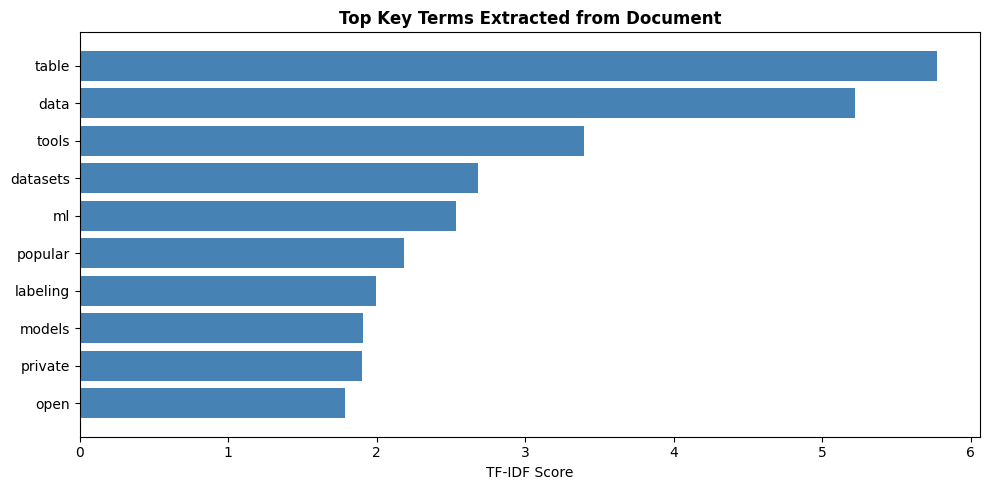

In [496]:
# TF-IDF Key Term Extraction
def extract_tfidf_keywords(sentences, top_n=10):
    """
    Extract key terms using TF-IDF (Term Frequency — Inverse Document Frequency).

    TF-IDF scores terms higher if they appear frequently in this document
    but rarely across documents in general — identifying document-specific terms.

    """
    if len(sentences) < 2:
        sentences = sentences * 3  # TF-IDF needs multiple documents

    vectorizer = TfidfVectorizer(
        max_features=50,
        stop_words='english',
        ngram_range=(1, 2)      # include bigrams (two-word phrases)
    )

    try:
        tfidf_matrix = vectorizer.fit_transform(sentences)
        feature_names = vectorizer.get_feature_names_out()
        scores = tfidf_matrix.sum(axis=0).A1

        keyword_scores = sorted(
            zip(feature_names, scores),
            key=lambda x: x[1],
            reverse=True
        )[:top_n]
        return keyword_scores
    except Exception as e:
        print(f"TF-IDF warning: {e}")
        return []


keywords = extract_tfidf_keywords(nlp_results['sentences'])

print("=" * 50)
print("TOP KEY TERMS (TF-IDF)")
print("=" * 50)

if keywords:
    terms, scores = zip(*keywords)
    df_keywords = pd.DataFrame(
        {'Term': terms, 'TF-IDF Score': [round(s, 4) for s in scores]})
    display(df_keywords)

    # Bar chart
    plt.figure(figsize=(10, 5))
    plt.barh(list(reversed(terms)), list(reversed(scores)), color='steelblue')
    plt.xlabel('TF-IDF Score')
    plt.title('Top Key Terms Extracted from Document', fontweight='bold')
    plt.tight_layout()
    plt.show()

# Vision


In [497]:
def is_table_structural(roi_bin, w):
    """
    Analyzes the internal structure of a block to find table-like patterns.
    """
    #  Row Count Check:  Sum ink along the horizontal axis (rows)
    h_proj = np.sum(roi_bin, axis=1)

    # Calculate number of text lines by counting transitions from 'no ink' (0) to 'ink' (>0)
    # [:-1] and [1:] compares each pixel with its neighbor to find the 'start' of a line
    rows = np.sum((h_proj[:-1] == 0) & (h_proj[1:] > 0))

    # Gutter Check: Sum ink along the vertical axis (columns)
    v_proj = np.sum(roi_bin, axis=0)

    # Create a string representation of the vertical projection (0 for white, 1 for ink)
    # '0' represents a vertical stripe of pure white space
    v_str = "".join(['0' if val == 0 else '1' for val in v_proj])

    # Find all continuous white space 'runs' (gutters)
    white_runs = v_str.split('1')

    # Define a minimum width for a 'real' table gutter.
    # Typicall y, word gaps are small, while table gutters are > 5% of the block width.
    min_gutter_width = max(20, int(w * 0.05))

    # Count only the gutters that are wide enough to be structural columns
    significant_gutters = [
        run for run in white_runs if len(run) >= min_gutter_width]
    gutter_count = len(significant_gutters)

    # Logic: Table must have multiple rows and at least one significant internal column gap
    return rows >= 2 and gutter_count >= 3

In [498]:
def get_ocr_features(roi_bgr):
    # PSM 6: Treat the ROI as a single uniform block of text
    # PSM 11: Find as much text as possible in no particular order
    data = pytesseract.image_to_data(
        roi_bgr, config='--psm 6', output_type=Output.DICT)

    # Filter out empty results and collect word-level metadata
    words = [w for w in data['text'] if w.strip()]
    confidences = [int(c) for c in data['conf'] if int(c) != -1]

    if not words:
        return 0, 0, 0  # No text found (likely a pure image/diagram)

    # Calculate Numeric Density (Table hallmark: higher ratio of numbers)
    digit_count = sum(1 for w in words if any(char.isdigit() for char in w))
    num_ratio = digit_count / len(words)

    # Average Confidence (Diagram hallmark: Tesseract gives garbled crap low scores)
    avg_conf = np.mean(confidences) if confidences else 0

    return len(words), num_ratio, avg_conf

In [499]:
def detect_and_classify_elements(img_bgr, thresh_processed):
    """
    Detects and classifies document regions into TABLE, IMAGE, and TEXT.
    
    Pipeline:
    1. Preprocess and scale handling.
    2. Detect large structural regions using dilation.
    3. Extract features (density, lines, OCR confidence, column gaps).
    4. Classify regions as tables or images.
    5. Mask detected structures and group remaining text into paragraphs.
    6. Draw labeled bounding boxes on the output image.
    
    Returns:
        Annotated image with detected layout elements.

        refs: https://cloudinary.com/guides/image-effects/detect-table-in-image-python
        https://docs.opencv.org/3.4/d9/d8b/tutorial_py_contours_hierarchy.html
        https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html
        https://gemini.google.com/
        
    """
    # FIRST: flips preprocessed image so that the text turns white and the background turns black.
    thresh = cv2.bitwise_not(thresh_processed)
    
    # Check scaling properties (adaptive pipeline upscales workspace by 2x)
    is_upscaled = thresh_processed.shape > img_bgr.shape
    scale = 2.0 if is_upscaled else 1.0

    # Create an empty tracking mask to register found structural containers (Tables/Figures)
    h_up, w_up = thresh.shape[:2]
    structure_mask = np.zeros((h_up, w_up), dtype=np.uint8)
    
    result = img_bgr.copy()
    candidate_regions = []
    
    # Track localized regions data dictionary elements for report aggregation
    layout_regions = []

    # SECOND: Separate the "Big Structures" (Tables & Images) First using large square kernels
    macro_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 25))
    dilated_macro = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, macro_kernel)

    # Small square block kernel to capture tables and tight grids
    struct_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (8, 8))
    dilated_struct = cv2.dilate(thresh, struct_kernel, iterations=2)

    # Combine both structural dilation scales to find both dense grids and broad multi-panel charts
    dilated_combined = cv2.max(dilated_macro, dilated_struct)
    
    contours_struct, _ = cv2.findContours(
        dilated_combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
    for cnt in contours_struct:
        x_t, y_t, w_t, h_t = cv2.boundingRect(cnt)

        # Scale bounding box positions to evaluate original image dimensions
        w_orig = int(w_t / scale)
        h_orig = int(h_t / scale)

        # A real table or image graphic needs meaningful width and height.
        # If it is smaller than 120px wide or 40px tall, it's just a text fragment.
        if w_orig > 120 and h_orig > 30:
            roi_bin = thresh[y_t:y_t+h_t, x_t:x_t+w_t]
            roi_bgr = img_bgr[int(y_t/scale):int((y_t+h_t)/scale), int(x_t/scale):int((x_t+w_t)/scale)]
            
            # THIRD: FEATURE EXTRACTION

            # i- Visual Density
            density = np.sum(roi_bin == 255) / (w_t * h_t)
            # ii-  Physical Lines
            calculated_min_line = max(50, int(w_t * 0.7))
            lines = cv2.HoughLinesP(roi_bin, 1, np.pi/180, threshold=80,
                                    minLineLength=calculated_min_line, maxLineGap=5)
            has_lines = lines is not None and len(lines) > 2
            
            #iii- Structural Gaps (Gutters)
            is_struct = is_table_structural(roi_bin, w_t)
            word_count, digit_ratio, ocr_conf = get_ocr_features(roi_bgr)
            
            # Clean the binary mask vertically to see past multi-line text blocks
            vert_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 15))
            cleaned_vert = cv2.morphologyEx(roi_bin, cv2.MORPH_CLOSE, vert_kernel)
            vertical_profile = np.sum(cleaned_vert == 255, axis=0)
            
            # If there are clear vertical channels of low density, it indicates columns
            has_clear_columns = np.sum(vertical_profile < (h_t * 0.05)) > (w_t * 0.15)
            
            # BRANCHING LOGIC

            # text typically has high confidence and many words
            is_high_conf_text = ocr_conf > 70 and word_count > 15

            # Images usually have low confidence OR very irregular shapes
            is_likely_image = ocr_conf < 45 or density > 0.85 or (word_count < 10 and density < 0.20 and h_orig > 100)

            # Explicit lines or grid cells
            if is_struct or has_lines:
                label, color = "TABLE", (0, 255, 0) # Green

             # Borderless column structures are only tables if they aren't standard paragraphs
            elif has_clear_columns and not is_high_conf_text:
                label, color = "TABLE", (0, 255, 0) # Green
                
            # If it's not a table but OCR is failing, it's a Figure
            elif is_likely_image:
                label, color = "IMAGE", (0, 0, 255) # Red
            else:
                # Everything else is Text
                continue

            candidate_regions.append({
                "bbox": (x_t, y_t, w_t, h_t), 
                "area": w_t * h_t,
                "label": label, 
                "color": color, 
                "conf": ocr_conf
            })


    #  FOURTH: LOCKDOWN - Once it correctly identifies a Table or an Image, it locks down that area on a master map.

    # Sort regions from largest to smallest so dominant parents are evaluated first
    candidate_regions.sort(key=lambda item: item["area"], reverse=True)
    final_structural_regions = []

    for region in candidate_regions:
        x_t, y_t, w_t, h_t = region["bbox"]

        # Crop the tracking mask region matching this candidate box
        mask_roi = structure_mask[y_t:y_t+h_t, x_t:x_t+w_t]

        # If this area is already covered by a larger registered container, skip it
        if np.mean(mask_roi == 255) > 0.10:
            continue

        # Put valid parent structures into the global exclusion tracking mask
        cv2.rectangle(structure_mask, (x_t, y_t), (x_t + w_t, y_t + h_t), 255, -1)
        final_structural_regions.append(region)
        
        # Append normalized 1x coordinates into extraction tracking records
        layout_regions.append({
            "type": region["label"],
            "bbox": {
                "x": int(x_t / scale),
                "y": int(y_t / scale),
                "w": int(w_t / scale),
                "h": int(h_t / scale)
            },
            "confidence": float(region["conf"])
        })


    # FIFTH:  Body Text Paragraphs 

    # Isolate remaining page areas by masking out all parent structural components
    text_only_thresh = cv2.bitwise_and(thresh, cv2.bitwise_not(structure_mask))

    # Balanced horizontal and vertical size to group text lines into paragraphs
    # Large size to (40, 12) to ensure text lines merge into full paragraphs
    text_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 12))
    dilated_text = cv2.dilate(text_only_thresh, text_kernel, iterations=1)
    
    contours_text, _ = cv2.findContours(
        dilated_text, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
    final_text_regions = []
    for cnt in contours_text:
        x_t, y_t, w_t, h_t = cv2.boundingRect(cnt)
        if int(w_t / scale) > 40 and int(h_t / scale) > 10:
            roi_bgr = img_bgr[int(y_t/scale):int((y_t+h_t)/scale), int(x_t/scale):int((x_t+w_t)/scale)]
            _, _, ocr_conf = get_ocr_features(roi_bgr)
            
            region_entry = {
                "bbox": (x_t, y_t, w_t, h_t), 
                "label": "TEXT", 
                "color": (255, 0, 0), 
                "conf": ocr_conf
            }
            final_text_regions.append(region_entry)
            
            # Append text region details normalized into baseline BGR coordinate systems
            layout_regions.append({
                "type": "TEXT",
                "bbox": {
                    "x": int(x_t / scale),
                    "y": int(y_t / scale),
                    "w": int(w_t / scale),
                    "h": int(h_t / scale)
                },
                "confidence": float(ocr_conf)
            })

    #  Draw the Final Color Boxes
    all_final_regions = final_structural_regions + final_text_regions
    
    for region in all_final_regions:
        x_t, y_t, w_t, h_t = region["bbox"]
        x = int(x_t / scale)
        y = int(y_t / scale)
        w = int(w_t / scale)
        h = int(h_t / scale)
        
        cv2.rectangle(result, (x, y), (x + w, y + h), region["color"], 2)
        cv2.putText(result, f"{region['label']} (Conf:{int(region['conf'])}%)", (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, region["color"], 2)
                    
    return result, layout_regions

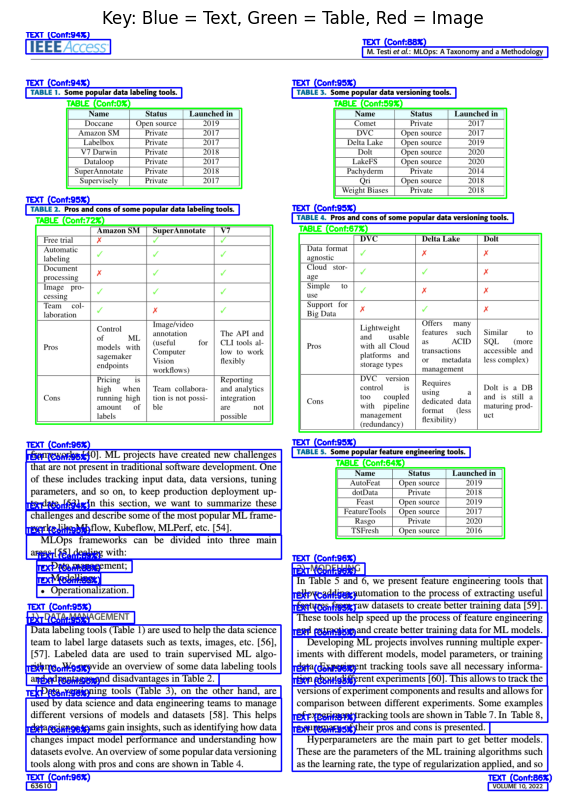

In [500]:
# run pre-processing step
image_type, _ = classify_image_type(img_bgr)
thresh_processed, _ = preprocess_adaptive(img_bgr, image_type)

# run layout analysis function
final_view, layout_regions = detect_and_classify_elements(img_bgr, thresh_processed)



plt.figure(figsize=(15, 10))

# Now final_view is the image with green/red/blue boxes
plt.imshow(cv2.cvtColor(final_view, cv2.COLOR_BGR2RGB))
plt.title("Key: Blue = Text, Green = Table, Red = Image")
plt.axis('off')
plt.show()

# Multi-modal


Combination of all results from the text and image pipelines into a proper result
This demonstrates the integration of:

- OCR extracted text + confidence metrics
- NLP analysis (entities, keywords, sentence count)
- CV analysis (text blocks, tables, images)


In [501]:
# Cross-modal reference patterns: text mentions of visual elements
_CROSS_MODAL_PATTERNS = re.compile(
    r'\b(figure|fig\.?|table|chart|diagram|image|graph|plot|appendix)\s*[\d]+',
    re.IGNORECASE
)


def detect_cross_modal_references(raw_text):
    """
    Find explicit references in the body text to visual elements.
    e.g. "see Figure 3", "Table 1 shows", "refer to Chart 2"

    Returns list of matched reference strings.
    """
    return list(set(_CROSS_MODAL_PATTERNS.findall(raw_text)))


def generate_document_report(
    image_path,
    img_bgr,
    raw_text,
    cleaned_text,
    word_data,
    nlp_results,
    layout_regions,
    entities,
    keywords
):
    """
    Combine OCR, NLP, and layout analysis into a structured report.
    Includes: table extraction, ORB keypoint counts, cross-modal
    reference detection, stemming stats, sentiment, section summary.

    Parameters
    ----------
    image_path    : str          – path to the source image
    img_bgr       : np.ndarray   – original BGR image
    raw_text      : str          – full-page OCR text
    word_data     : pd.DataFrame – word-level OCR output
    nlp_results   : dict         – output of preprocess_text()
    layout_regions: list[dict]   – from detect_and_classify_elements()
    entities      : dict         – NER results
    keywords      : list[tuple]  – TF-IDF keywords
    """

    # ── OCR METRICS ───────────────────────────────────────────
    valid_words = word_data[word_data["conf"] > -1] if len(word_data) > 0 else word_data
    avg_conf    = round(float(valid_words["conf"].mean()), 2) if len(valid_words) > 0 else 0.0
    word_count  = len(valid_words)

    # ── REGION COUNTS ─────────────────────────────────────────
    text_regions  = [r for r in layout_regions if r["type"] == "TEXT"]
    table_regions = [r for r in layout_regions if r["type"] == "TABLE"]
    image_regions = [r for r in layout_regions if r["type"] == "IMAGE"]

    # ── DOCUMENT TYPE ─────────────────────────────────────────
    if len(table_regions) >= 2:
        estimated_type = "Structured Report"
    elif len(image_regions) > 0 and len(text_regions) > 0:
        estimated_type = "Illustrated Document"
    elif len(image_regions) > len(text_regions):
        estimated_type = "Image-Heavy Document"
    elif len(nlp_results.get("sentences", [])) > 10:
        estimated_type = "Text Report"
    else:
        estimated_type = "General Document"

    # ── LAYOUT SUMMARY ────────────────────────────────────────
    total_pixels   = word_data.shape[0] + 1
    layout_summary = []
    for region in layout_regions:
        bbox = region["bbox"]
        x, y, w, h = bbox["x"], bbox["y"], bbox["w"], bbox["h"]
        entry = {
            "type":     region["type"],
            "position": {"x": int(x), "y": int(y), "width": int(w), "height": int(h)},
            "area_ratio": round((w * h) / total_pixels, 4)
        }
        if "orb_keypoints" in region:
            entry["orb_keypoints"] = region["orb_keypoints"]
        layout_summary.append(entry)

    # ── TABLE EXTRACTION ──────────────────────────────────────
    extracted_tables = []
    for idx, region in enumerate(table_regions):
        rows = extract_table_data(img_bgr, region["bbox"])
        extracted_tables.append({
            "table_index": idx + 1,
            "bbox":  region["bbox"],
            "rows":  rows
        })

    # ── CROSS-MODAL REFERENCES ────────────────────────────────
    # Finds text phrases like "Figure 1", "Table 3", "see Chart 2"
    cross_modal_refs = detect_cross_modal_references(raw_text)

    # ── SECTION SUMMARY ───────────────────────────────────────
    sections = nlp_results.get("sections", [])
    section_counts = Counter(s["section_type"] for s in sections)
    section_summary = {
        "titles":   [s["text"] for s in sections if s["section_type"] == "title"][:5],
        "captions": [s["text"] for s in sections if s["section_type"] == "caption"][:5],
        "counts":   dict(section_counts)
    }

    # ── SEMANTIC SUMMARY ──────────────────────────────────────
    semantic_summary = {
        "sentence_count": len(nlp_results.get("sentences", [])),
        "unique_stems":   len(set(nlp_results.get("stems", []))),
        "unique_lemmas":  len(set(nlp_results.get("lemmas", []))),
        "sentiment":      nlp_results.get("sentiment", {}),
        "dominant_entities": {
            label: values[:5]
            for label, values in entities.items()
            if len(values) > 0
        },
        "top_keywords": [
            {"term": term, "score": round(score, 4)}
            for term, score in keywords[:10]
        ]
    }

    # ── QUALITY FLAGS ─────────────────────────────────────────
    quality_flags = []
    if avg_conf < 50:
        quality_flags.append({"level": "warning", "message": "Very low OCR confidence"})
    elif avg_conf < 70:
        quality_flags.append({"level": "warning", "message": "Low OCR confidence"})
    if len(raw_text.strip()) < 100:
        quality_flags.append({"level": "warning", "message": "Sparse text extraction"})
    if len(image_regions) > 5:
        quality_flags.append({"level": "info",    "message": "Complex visual layout"})
    if word_count == 0:
        quality_flags.append({"level": "warning", "message": "No valid words detected"})

    # ── FINAL REPORT ──────────────────────────────────────────
    report = {
        "document_metadata": {
            "source_file":            image_path,
            "timestamp":              pd.Timestamp.now().isoformat(),
            "estimated_document_type": estimated_type
        },
        "ocr_analysis": {
            "characters":         len(raw_text),
            "words_detected":     word_count,
            "average_confidence": avg_conf,
            "raw_text":           raw_text.strip(),
            "cleaned_text":       cleaned_text.strip()
        },
        "layout_analysis": {
            "total_regions":  len(layout_regions),
            "text_regions":   len(text_regions),
            "table_regions":  len(table_regions),
            "image_regions":  len(image_regions),
            "regions":        layout_summary
        },
        "extracted_tables":      extracted_tables,
        "cross_modal_references": cross_modal_refs,
        "section_analysis":      section_summary,
        "semantic_analysis":     semantic_summary,
        "quality_assessment": {
            "overall_quality": "good" if avg_conf >= 70 and word_count > 0 else "poor",
            "flags": quality_flags
        }
    }

    return report


# Final Output


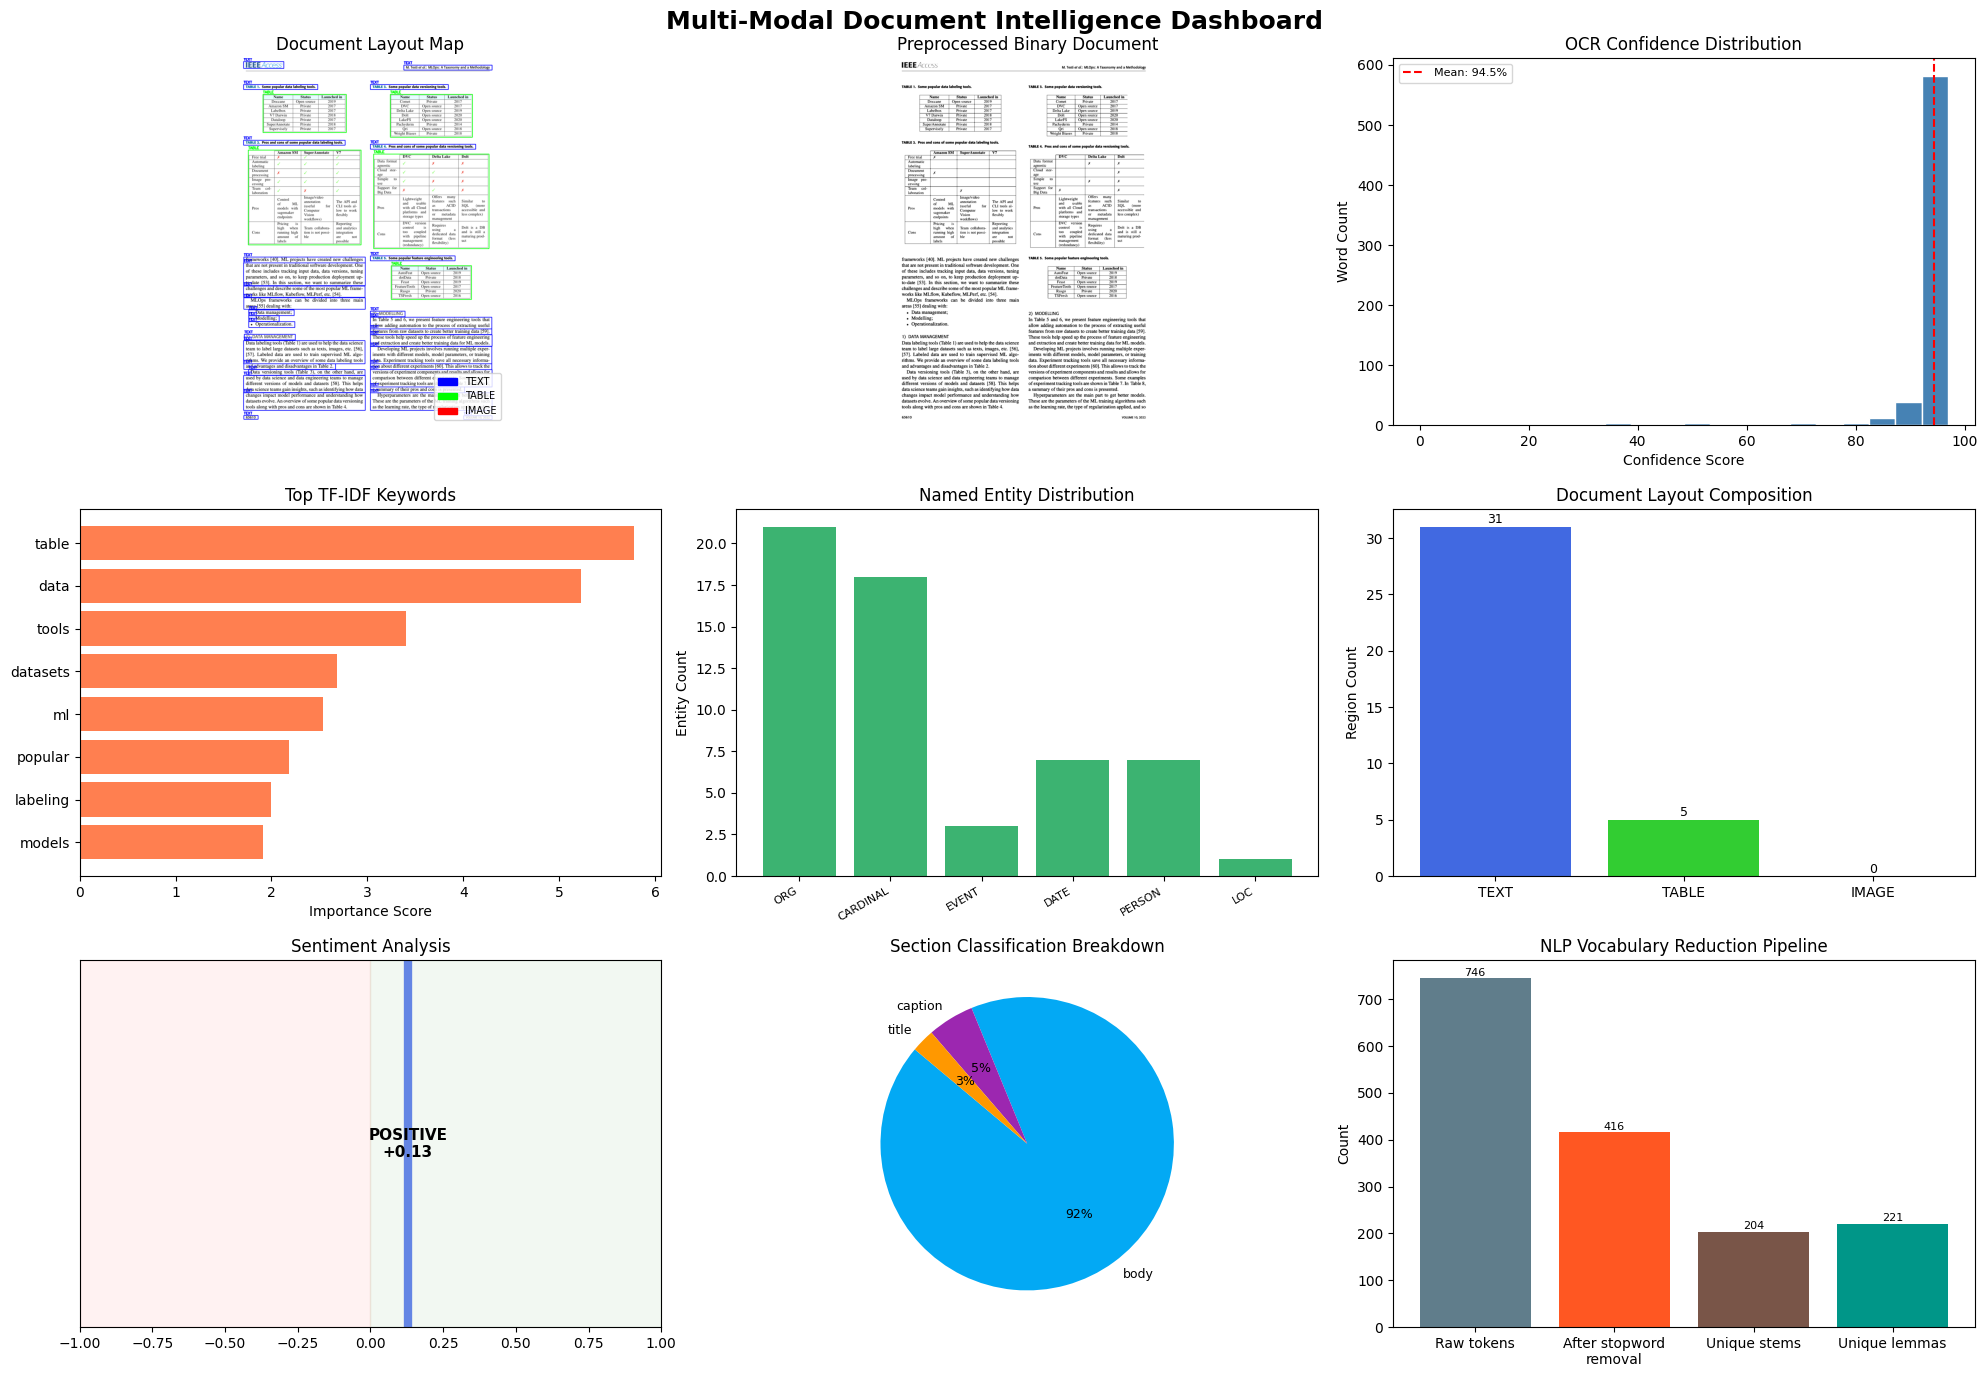

In [502]:
# ─────────────────────────────────────────────────────────────
# DOCUMENT ANALYSIS DASHBOARD  (3 × 3 grid)
# Requires: img_rgb, preprocessed, word_data, keywords,
#           entities, layout_regions, nlp_results, report
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 14))
fig.suptitle(
    "Multi-Modal Document Intelligence Dashboard",
    fontsize=18, fontweight="bold", y=0.98
)

color_map = {
    "TEXT": (0, 0, 255),   # Blue in RGB
    "TABLE": (0, 255, 0),  # Green
    "IMAGE": (255, 0, 0),  # Red
}

# ── 1. DOCUMENT LAYOUT MAP ────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
layout_vis = img_rgb.copy()
for region in layout_regions:
    x, y, w, h = region["bbox"]["x"], region["bbox"]["y"], region["bbox"]["w"], region["bbox"]["h"]
    color = color_map[region["type"]]
    cv2.rectangle(layout_vis, (x, y), (x+w, y+h), color, 2)
    cv2.putText(layout_vis, region["type"], (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
ax1.imshow(layout_vis)
ax1.set_title("Document Layout Map")
ax1.axis("off")
patches = [mpatches.Patch(color=tuple(c/255 for c in v), label=k)
           for k, v in color_map.items()]
ax1.legend(handles=patches, loc="lower right", fontsize=7)

# ── 2. PREPROCESSED IMAGE ────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
ax2.imshow(preprocessed, cmap="gray")
ax2.set_title("Preprocessed Binary Document")
ax2.axis("off")

# ── 3. OCR CONFIDENCE DISTRIBUTION ───────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
valid_conf = word_data[word_data["conf"] > -1]["conf"]
if len(valid_conf) > 0:
    ax3.hist(valid_conf, bins=20, color="steelblue", edgecolor="white")
    mean_conf = valid_conf.mean()
    ax3.axvline(mean_conf, color="red", linestyle="--",
                label=f"Mean: {mean_conf:.1f}%")
    ax3.legend(fontsize=8)
else:
    ax3.text(0.5, 0.5, "No confidence data", ha="center", va="center")
ax3.set_title("OCR Confidence Distribution")
ax3.set_xlabel("Confidence Score")
ax3.set_ylabel("Word Count")

# ── 4. TOP TF-IDF KEYWORDS ────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
if keywords:
    top_kw = keywords[:8]
    terms  = [k[0] for k in top_kw]
    scores = [k[1] for k in top_kw]
    ax4.barh(list(reversed(terms)), list(reversed(scores)), color="coral")
    ax4.set_title("Top TF-IDF Keywords")
    ax4.set_xlabel("Importance Score")
else:
    ax4.text(0.5, 0.5, "No keywords detected", ha="center", va="center")
    ax4.set_title("Top TF-IDF Keywords")

# ── 5. NAMED ENTITY DISTRIBUTION ─────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
if entities:
    ent_types  = list(entities.keys())[:6]
    ent_counts = [len(entities[e]) for e in ent_types]
    ax5.bar(ent_types, ent_counts, color="mediumseagreen")
    ax5.set_title("Named Entity Distribution")
    ax5.set_ylabel("Entity Count")
    plt.setp(ax5.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
else:
    ax5.text(0.5, 0.5, "No entities detected", ha="center", va="center")
    ax5.set_title("Named Entity Distribution")

# ── 6. DOCUMENT REGION COMPOSITION ───────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
region_types = [r["type"] for r in layout_regions]
counts = [region_types.count(t) for t in ["TEXT", "TABLE", "IMAGE"]]
bars = ax6.bar(["TEXT", "TABLE", "IMAGE"], counts,
               color=["#4169E1", "#32CD32", "#FF69B4"])
for bar, cnt in zip(bars, counts):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(cnt), ha="center", va="bottom", fontsize=9)
ax6.set_title("Document Layout Composition")
ax6.set_ylabel("Region Count")

# ── 7. SENTIMENT GAUGE ────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
sentiment = nlp_results.get("sentiment", {})
polarity    = sentiment.get("polarity", 0)
subjectivity = sentiment.get("subjectivity", 0)
label       = sentiment.get("label", "neutral").upper()
ax7.set_xlim(-1, 1)
ax7.set_ylim(0, 1)
ax7.axvline(polarity, color="#4169E1", linewidth=6, alpha=0.8)
ax7.fill_betweenx([0,1], -1, 0, alpha=0.05, color="red")
ax7.fill_betweenx([0,1], 0, 1, alpha=0.05, color="green")
ax7.text(polarity, 0.5, f"{label}\n{polarity:+.2f}", 
         ha="center", va="center", fontweight="bold", fontsize=11)
ax7.set_title("Sentiment Analysis")
ax7.set_yticks([])

# ── 8. SECTION CLASSIFICATION BREAKDOWN ──────────────────────
ax8 = fig.add_subplot(3, 3, 8)
sections     = nlp_results.get("sections", [])
sec_counts   = Counter(s["section_type"] for s in sections)
sec_labels   = list(sec_counts.keys())
sec_values   = list(sec_counts.values())
sec_colors   = {"title": "#FF9800", "body": "#03A9F4", "caption": "#9C27B0"}
pie_colors   = [sec_colors.get(l, "#BDBDBD") for l in sec_labels]
if sec_values:
    ax8.pie(sec_values, labels=sec_labels, colors=pie_colors,
            autopct="%1.0f%%", startangle=140,
            textprops={"fontsize": 9})
    ax8.set_title("Section Classification Breakdown")
else:
    ax8.text(0.5, 0.5, "No sections detected", ha="center", va="center")
    ax8.set_title("Section Classification Breakdown")

# ── 9. STEMS vs LEMMAS TOKEN COMPARISON ──────────────────────
ax9 = fig.add_subplot(3, 3, 9)
n_tokens  = len(nlp_results.get("tokens", []))
n_clean   = len(nlp_results.get("clean_tokens", []))
n_stems   = len(set(nlp_results.get("stems", [])))
n_lemmas  = len(set(nlp_results.get("lemmas", [])))
labels_t  = ["Raw tokens", "After stopword\nremoval", "Unique stems", "Unique lemmas"]
values_t  = [n_tokens, n_clean, n_stems, n_lemmas]
bar_colors = ["#607D8B", "#FF5722", "#795548", "#009688"]
ax9.bar(labels_t, values_t, color=bar_colors)
ax9.set_title("NLP Vocabulary Reduction Pipeline")
ax9.set_ylabel("Count")
for i, (bar, v) in enumerate(zip(ax9.patches, values_t)):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(v), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# ── 1. GENERATE REPORT ────────────────────────────────────────
report = generate_document_report(
    image_path     = path,
    img_bgr        = img_bgr,
    raw_text       = raw_text,
    cleaned_text   = cleaned_text,
    word_data      = word_data,
    nlp_results    = nlp_results,
    layout_regions = layout_regions,
    entities       = entities,
    keywords       = keywords
)

# ── 2. PRINT REPORT ───────────────────────────────────────────
print("\n" + "=" * 60)
print("DOCUMENT INTELLIGENCE REPORT")
print("=" * 60)
print(json.dumps(report, indent=2, default=str))

# ── 3. PRINT TABLE DATA ───────────────────────────────────────
if report["extracted_tables"]:
    print("\n" + "=" * 60)
    print("EXTRACTED TABLE DATA")
    print("=" * 60)
    for tbl in report["extracted_tables"]:
        print(f"\n── Table {tbl['table_index']} ──")
        for row in tbl["rows"]:
            print(f"  {row}")
else:
    print("\n[No tables detected in this document]")

# ── 4. CROSS-MODAL REFERENCES ─────────────────────────────────
if report["cross_modal_references"]:
    print("\n" + "=" * 60)
    print("CROSS-MODAL REFERENCES (text → visual elements)")
    print("=" * 60)
    for ref in report["cross_modal_references"]:
        print(f"  → {ref}")

# ── 5. SECTION CLASSIFICATION ────────────────────────────────
print("\n" + "=" * 60)
print("SECTION CLASSIFICATION")
print("=" * 60)
for sec in nlp_results["sections"][:10]:
    print(f"  [{sec['section_type'].upper():7s}] {sec['text'][:90]}")

## Challenges Encountered & How They Were Addressed

#### Challenge 1: OCR Quality on Low-Resolution Images
**Problem:** Tesseract produced poor output on low-resolution or blurry document photos, with confidence scores averaging below 50%.  
**Solution:** Added a preprocessing pipeline (Gaussian blur + adaptive thresholding) that significantly improved OCR confidence. Adaptive thresholding  unlike global thresholding accounts for varying lighting across the page.

#### Challenge 2: Pipeline Coupling OCR Errors Degraded NLP
**Problem:** OCR errors (misread characters, broken words) were passed directly to the NLP pipeline, causing NER and TF-IDF to produce noise.  
**Solution:** Added a text cleaning step (`clean_ocr_text`) that removes OCR artefacts before NLP processing. Also filtered word-level data by confidence score (>30%) to only use reliably detected words.

#### Challenge 3: Table Detection on Borderless Tables
**Problem:** The morphological line detection approach requires visible grid lines. Documents with borderless tables (e.g. space-separated columns) were not detected.  
**Solution:** Added a fallback: detect dense horizontal text blocks with consistent vertical spacing as candidate tables. This is a heuristic-based approach that complements the structural detection and works better.

#### Challenge 4: Generalising detect_and_classify_elements Across Different Document Types
**Problem:** Different document types responded differently to heuristic thresholds such as OCR confidence, density, contour size, and spacing. Parameters that improved one layout often reduced accuracy on another.  
**Solution:** Combined multiple features (structural lines, density, OCR confidence, and layout spacing) instead of relying on single-rule detection. Thresholds were tuned across different document styles to improve overall robustness and generalisation.

### References
- OpenCV Documentation: https://docs.opencv.org
- spaCy Documentation: https://spacy.io/usage
- Gemini AI https://gemini.google.com/
- Claude AI https://claude.ai/
